In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np
import os

In [2]:
arr = xr.open_zarr("output_aq_rm.zarr")

/tmp/ipykernel_43/4042014749.py:1: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  arr = xr.open_zarr("output_aq_rm.zarr")


In [3]:
arr.pt.shape

(160, 6, 24, 24, 79)

In [4]:
from cartopy import crs as ccrs
from fv3viz import pcolormesh_cube

/usr/local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
pt=arr.pt

In [6]:
ptn=pt.to_numpy()

In [7]:
# for i in range(ptn.shape[0]):
print(ptn[-2,:].max(), ptn[-2,:].min())
# ptn[-1,:].max()

441.60779727427735 199.97997167532714


In [8]:
np.argwhere(ptn[1,:] > 0)

array([[ 0,  0,  0,  0],
       [ 0,  0,  0,  1],
       [ 0,  0,  0,  2],
       ...,
       [ 5, 23, 23, 76],
       [ 5, 23, 23, 77],
       [ 5, 23, 23, 78]])

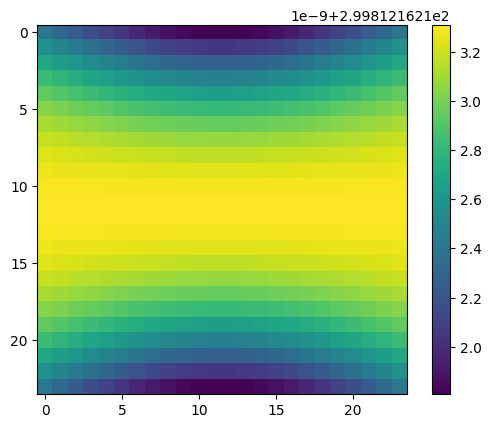

In [9]:
plt.imshow(ptn[0, 1, :, :, -1].transpose())
plt.colorbar()

In [10]:
temperature=ptn[-2,:]

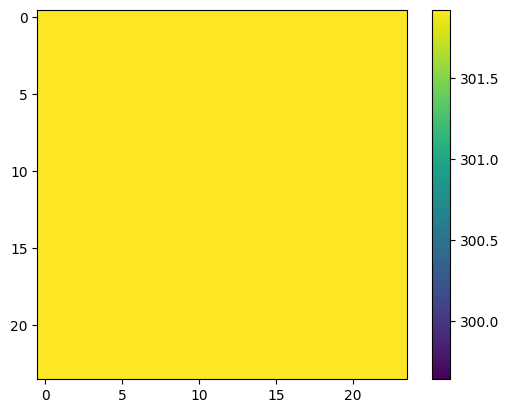

In [11]:
fig = plt.figure() # make figure

# make axesimage object
# the vmin and vmax here are very important to get the color map correct
im = plt.imshow(ptn[0, 1, :, :, -1].transpose(), cmap=plt.get_cmap('viridis'), vmin=299, vmax=322)
plt.colorbar()

# function to update figure
def updatefig(j):
    # set the data in the axesimage object
    im.set_array(ptn[j, 1, :, :, -1].transpose())
    im.set_clim(vmin=ptn[:-29, 1, :, :, -1].min(), vmax=ptn[:-29, 1, :, :, -1].max())
    # return the artists set
    return [im]
# kick off the animation
ani = animation.FuncAnimation(fig, updatefig, frames=range(ptn.shape[0]-1), interval=50, blit=True)
# plt.show()
from IPython.display import HTML
HTML(ani.to_jshtml())

In [12]:
lats = np.load("lats.npy")
lons = np.load("lons.npy")
fswd = arr.fswd.to_numpy()
nx = fswd.shape[2]

In [13]:
print(fswd.shape, lats.shape, lons.shape)

(160, 6, 24, 24, 80) (6, 25, 25) (6, 25, 25)


In [14]:
fig2 = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection=ccrs.Robinson())
ax.set_title(f"TOA Downward SW Radiation ({nx} x {nx} points per tile)")
f2 = pcolormesh_cube(
        lats,
        lons,
        fswd[0, :, :, :, 0],
        cmap="viridis",
        ax=ax
    )
plt.colorbar(f2, label="SW Radiation (W/m**2)")
artists = []

for t in range(fswd.shape[0]):
    print(t)
    f2 = pcolormesh_cube(
        lats,
        lons,
        fswd[t, :, :, :, 0],
        cmap="viridis",
        ax=ax
    )
    artists.append(f2)
    
ani = animation.ArtistAnimation(fig=fig, artists=artists, interval=400)
plt.show()

0


/tmp/ipykernel_43/1744078111.py:11: UserWarning: Adding colorbar to a different Figure <Figure size 640x480 with 4 Axes> than <Figure size 1200x600 with 0 Axes> which fig.colorbar is called on.
  plt.colorbar(f2, label="SW Radiation (W/m**2)")


1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159


<Figure size 1200x600 with 0 Axes>

Text(0.5, 1.0, 'TOA Downward SW Radiation (24 x 24 points per tile)')

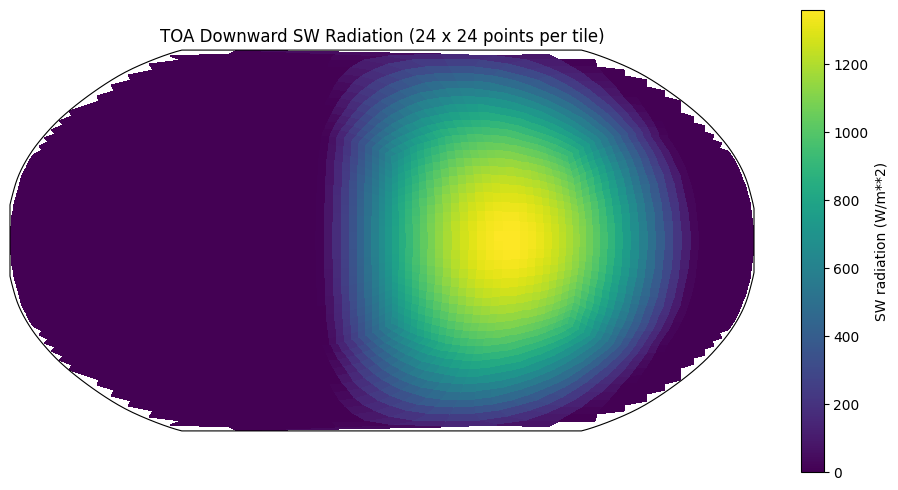

In [15]:
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection=ccrs.Robinson())
f2 = pcolormesh_cube(
    lats,
    lons,
    fswd[0, :, :, :, 0],
    cmap="viridis",
)
plt.colorbar(f2, label="SW radiation (W/m**2)")
ax.set_title(f"TOA Downward SW Radiation ({nx} x {nx} points per tile)")

Text(0.5, 1.0, 'TOA Downward SW Radiation (24 x 24 points per tile)')

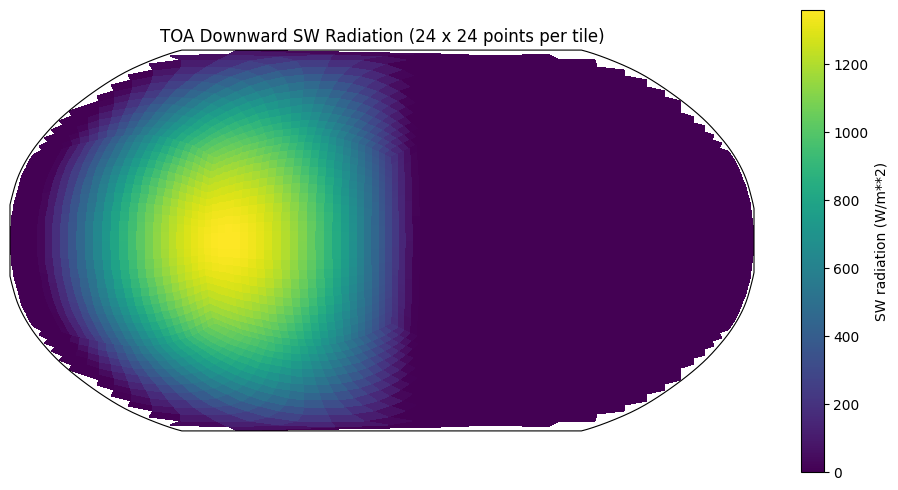

In [16]:
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection=ccrs.Robinson())
f2 = pcolormesh_cube(
    lats,
    lons,
    fswd[-1, :, :, :, 0],
    cmap="viridis",
)
plt.colorbar(f2, label="SW radiation (W/m**2)")
ax.set_title(f"TOA Downward SW Radiation ({nx} x {nx} points per tile)")

In [17]:
px = 6
py = 8

hsw = arr.hrtsw.to_numpy()[0, 1, px, py, :]*86400
hlw = arr.hrtlw.to_numpy()[0, 1, px, py, :]*86400

Heating is 0.0 + -8.669588279470467 = -8.669588279470467


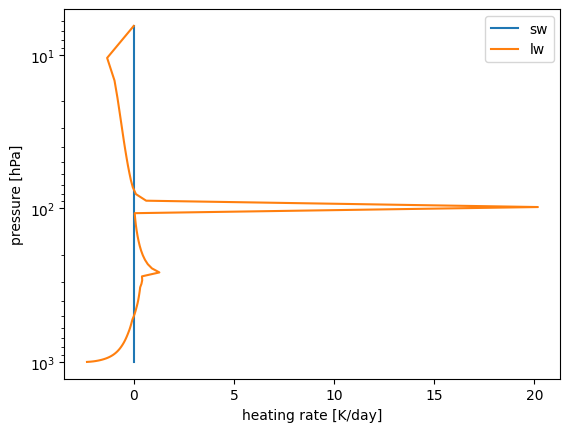

In [18]:
plt.gca().invert_yaxis()
plt.semilogy(hsw, arr.pe.to_numpy()[0, 1, px, py, 1:]/100, label="sw")
plt.semilogy(hlw, arr.pe.to_numpy()[0, 1, px, py, 1:]/100, label="lw")
plt.xlabel("heating rate [K/day]")
plt.ylabel("pressure [hPa]")
plt.legend()

print(f"Heating is {hsw.sum()} + {hlw.sum()} = {hsw.sum() + hlw.sum()}")

In [19]:
arr.hrtsw.to_numpy().shape

(160, 6, 24, 24, 79)

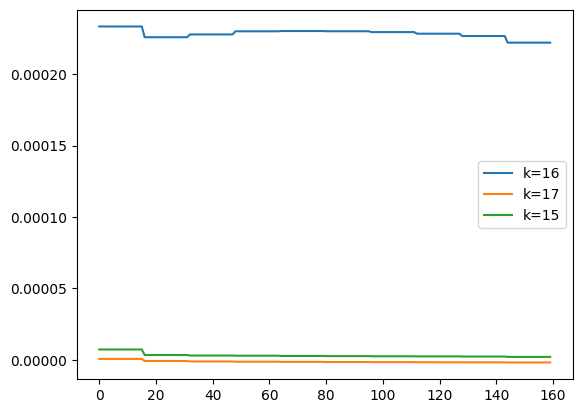

In [20]:
plt.plot(arr.hrtlw.to_numpy()[:, 1, px, py, 16], label="k=16")
plt.plot(arr.hrtlw.to_numpy()[:, 1, px, py, 17], label="k=17")
plt.plot(arr.hrtlw.to_numpy()[:, 1, px, py, 15], label="k=15")

plt.legend()

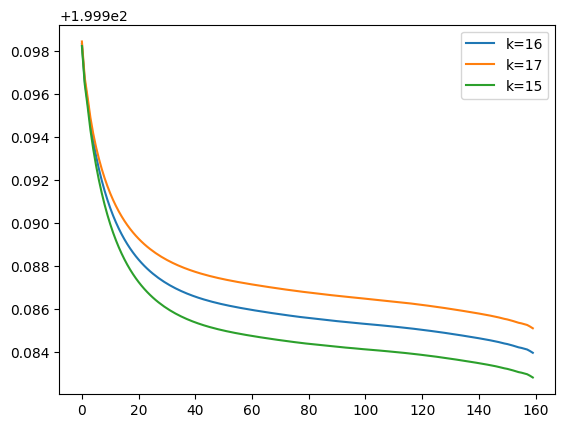

In [21]:
plt.plot(pt[:, 1, px, py, 16], label="k=16")
plt.plot(pt[:, 1, px, py, 17], label="k=17")
plt.plot(pt[:, 1, px, py, 15], label="k=15")

plt.legend()

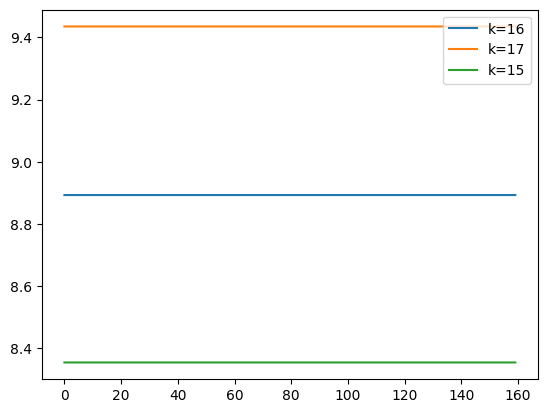

In [22]:
plt.plot(arr.delp.to_numpy()[:, 1, px, py, 16]/100, label="k=16")
plt.plot(arr.delp.to_numpy()[:, 1, px, py, 17]/100, label="k=17")
plt.plot(arr.delp.to_numpy()[:, 1, px, py, 15]/100, label="k=15")

plt.legend()

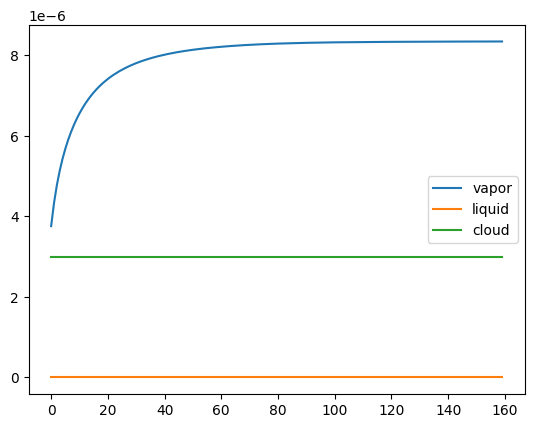

In [23]:
plt.plot(arr.qvapor.to_numpy()[:, 1, px, py, 16], label="vapor")
plt.plot(arr.qliquid.to_numpy()[:, 1, px, py, 16], label="liquid")
plt.plot(arr.qcld.to_numpy()[:, 1, px, py, 16], label="cloud")
plt.legend()

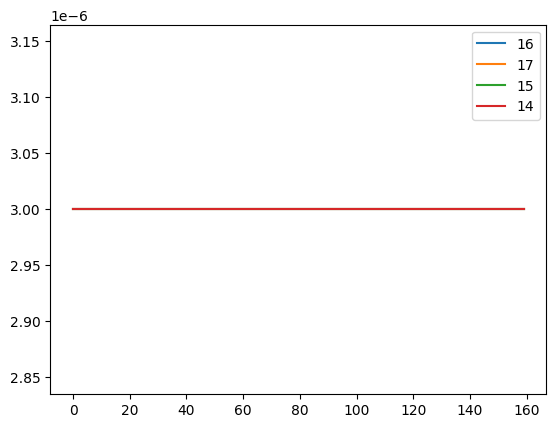

In [24]:
plt.plot(arr.qcld.to_numpy()[:, 1, px, py, 16], label="16")
plt.plot(arr.qcld.to_numpy()[:, 1, px, py, 17], label="17")
plt.plot(arr.qcld.to_numpy()[:, 1, px, py, 15], label="15")
plt.plot(arr.qcld.to_numpy()[:, 1, px, py, 14], label="14")
plt.legend()

Text(0.5, 1.0, 'BOA qvapor (24 x 24 points per tile)')

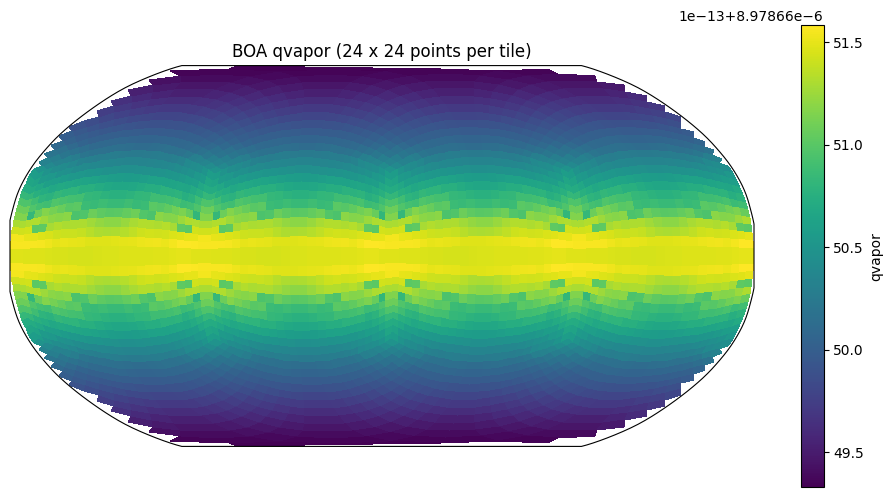

In [69]:
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection=ccrs.Robinson())
f2 = pcolormesh_cube(
    lats,
    lons,
    arr.qvapor.to_numpy()[-1, :, :, :,0],
    cmap="viridis",
)
plt.colorbar(f2, label="qvapor")
ax.set_title(f"BOA qvapor ({nx} x {nx} points per tile)")

Text(0.5, 1.0, 'BOA LW flux up (24 x 24 points per tile)')

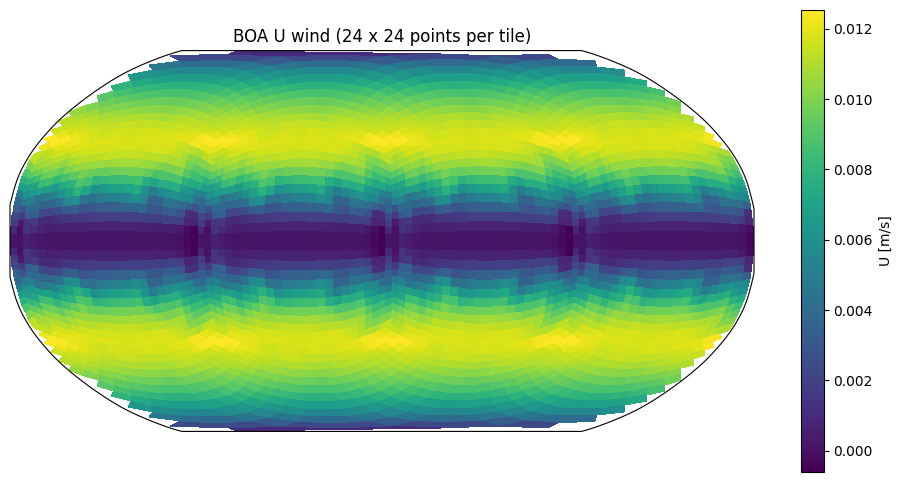

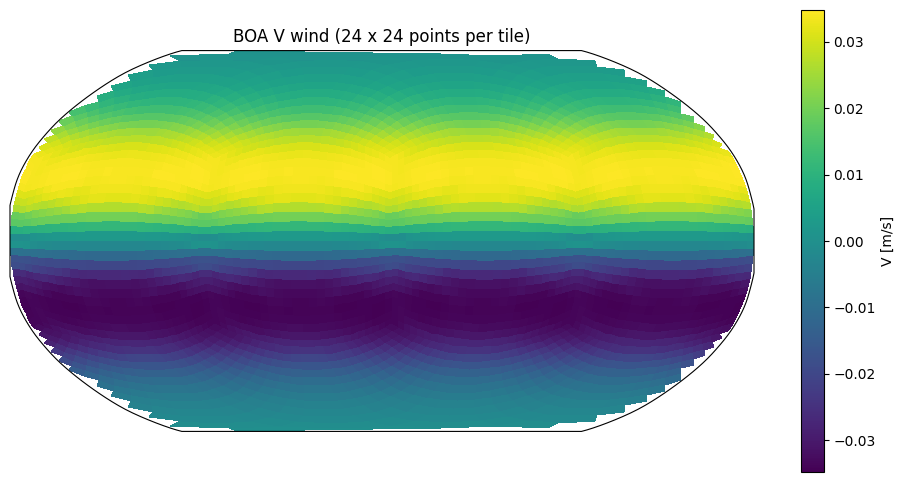

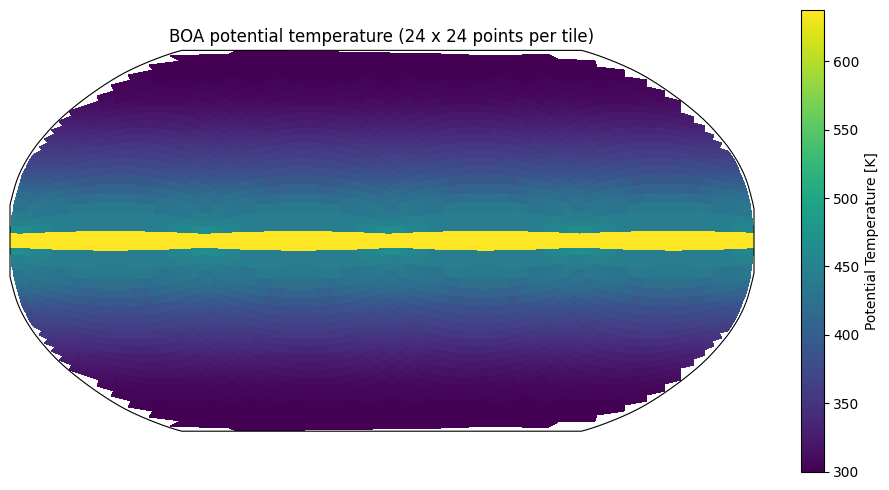

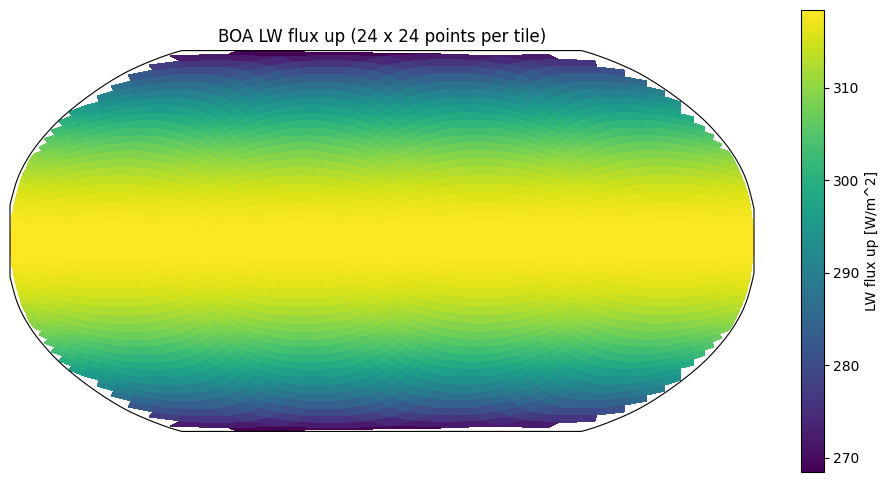

In [79]:
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection=ccrs.Robinson())
f1 = pcolormesh_cube(
    lats,
    lons,
    arr.ua.to_numpy()[-1, :, :, :,-1],
    cmap="viridis",
)
plt.colorbar(f1, label="U [m/s]")
ax.set_title(f"BOA U wind ({nx} x {nx} points per tile)")

fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection=ccrs.Robinson())
f2 = pcolormesh_cube(
    lats,
    lons,
    arr.va.to_numpy()[-1, :, :, :,-1],
    cmap="viridis",
)
plt.colorbar(f2, label="V [m/s]")
ax.set_title(f"BOA V wind ({nx} x {nx} points per tile)")

fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection=ccrs.Robinson())
f3 = pcolormesh_cube(
    lats,
    lons,
    ptn[-1, :, :, :,-1],
    cmap="viridis",
)
plt.colorbar(f3, label="Potential Temperature [K]")
ax.set_title(f"BOA potential temperature ({nx} x {nx} points per tile)")

fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection=ccrs.Robinson())
f3 = pcolormesh_cube(
    lats,
    lons,
    arr.flwu.to_numpy()[-1, :, :, :,17],
    cmap="viridis",
)
plt.colorbar(f3, label="LW flux up [W/m^2]")
ax.set_title(f"BOA LW flux up ({nx} x {nx} points per tile)")

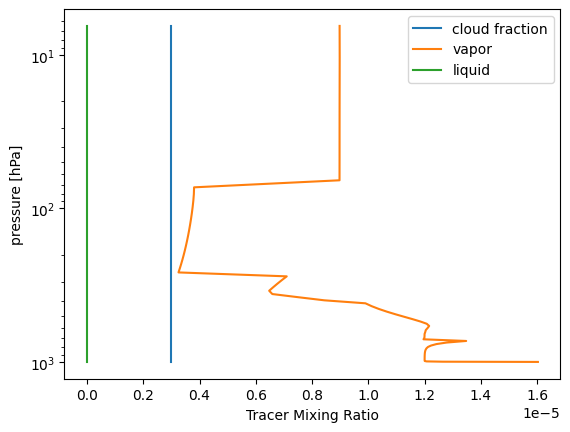

In [40]:
plt.gca().invert_yaxis()
plt.semilogy(arr.qcld.to_numpy()[0, 1, px, py, :], arr.pe.to_numpy()[0, 1, px, py, 1:]/100, label="cloud fraction")
plt.semilogy(arr.qvapor.to_numpy()[0, 1, px, py, :], arr.pe.to_numpy()[0, 1, px, py, 1:]/100, label="vapor")
plt.semilogy(arr.qliquid.to_numpy()[0, 1, px, py, :], arr.pe.to_numpy()[0, 1, px, py, 1:]/100, label="liquid")
plt.xlabel("Tracer Mixing Ratio")
plt.ylabel("pressure [hPa]")
plt.legend()

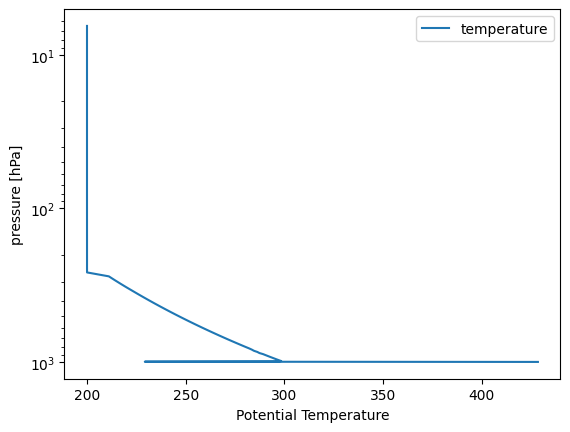

In [44]:
plt.gca().invert_yaxis()
plt.semilogy(arr.flwu.to_numpy()[-1, 1, px, py, :], arr.pe.to_numpy()[0, 1, px, py, 1:]/100, label="lw")
plt.xlabel("Potential Temperature")
plt.ylabel("pressure [hPa]")
plt.legend()

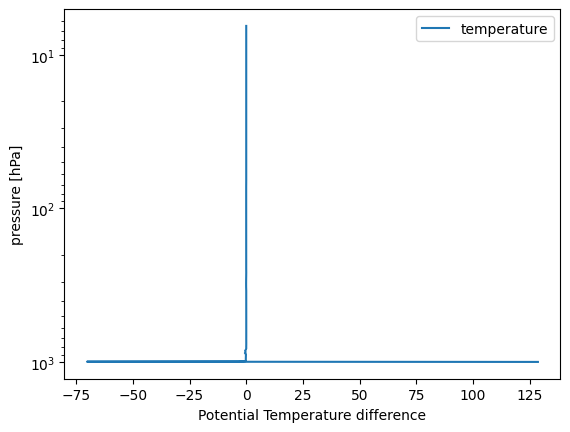

In [58]:
plt.gca().invert_yaxis()
plt.semilogy(ptn[-1, 1, px, py, :] - ptn[0, 1, px, py, :], arr.pe.to_numpy()[0, 1, px, py, 1:]/100, label="temperature")
plt.xlabel("Potential Temperature difference")
plt.ylabel("pressure [hPa]")
plt.legend()

(120.0, 160.0)

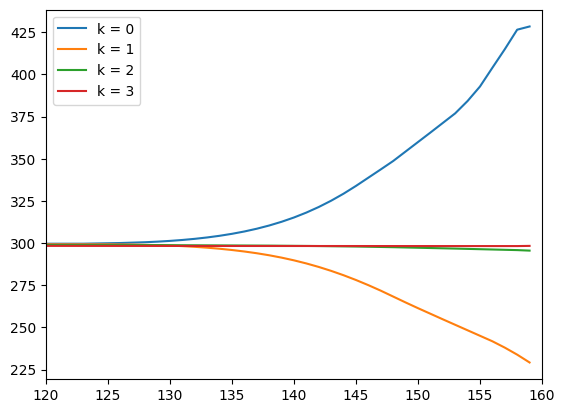

In [57]:
for k in range(4):
    plt.plot(ptn[:, 1, px, py, -1-k], label=f"k = {k}")
plt.legend()
plt.xlim((120,160))